# 📊 Diabetes Risk Prediction — Exploratory Data Analysis (EDA) & Feature Engineering

**Project**: Diabetes Risk Detection & Machine Learning Pipeline  
**Input Dataset**: `data/interim/cleaned_diabetes_risk_dataset.csv` (50,000 records, 37 validated columns)  
**Output Dataset**: `data/processed/engineered_diabetes_risk_dataset.csv` (50,000 records, engineered feature matrix)  

---

## 📌 Executive Summary & Objectives

Following data cleaning and leakage elimination, this notebook conducts a thorough **Exploratory Data Analysis (EDA)** and builds domain-specific **Feature Engineering** components to maximize machine learning model performance.

### 🎯 Key Workflow Stages
1. **Target & Class Balance Profiling**: Analyzing `Diabetes_Risk` tier distributions (High, Moderate, Low).
2. **Clinical Biomarker EDA**: Distribution and boxplot analysis of glycemic control features (`HbA1c`, `Fasting_Blood_Sugar`, `Blood_Glucose`), insulin levels, and lipid panels (`HDL`, `LDL`, `Triglycerides`, `Total_Cholesterol`).
3. **Lifestyle & Comorbidity Exploration**: Investigating relationships between physical activity, sleep, diet, stress, smoking, hypertension, fatty liver, PCOS, and diabetes risk.
4. **Domain-Specific Medical Feature Engineering**:
   - **Glycemic & Insulin Ratios**: `HbA1c_Glucose_Ratio`, `Glucose_Insulin_Ratio` (proxy for HOMA-IR insulin resistance).
   - **Atherogenic & Lipid Indices**: `Atherogenic_Index` ($\text{Triglycerides} / \text{HDL}$), `Total_Cholesterol_HDL_Ratio`, `LDL_HDL_Ratio`.
   - **Cardiovascular Metrics**: `Mean_Arterial_Pressure` ($\text{MAP}$), `Pulse_Pressure`.
   - **Composite Scores**: `Total_Active_Hours_Weekly`, `Metabolic_Syndrome_Risk_Score`, `Comorbidity_Count`.
5. **Categorical Encoding & Pipeline Preparation**: Ordinal encoding for ordered categories and One-Hot Encoding for nominal variables.
6. **Feature Importance & Final Export**: Evaluating engineered feature relevance via Random Forest importance and exporting `data/processed/engineered_diabetes_risk_dataset.csv`.


In [1]:
# Cell 1: Environment Setup, Libraries, & Plotting Settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings

# Styling & Display Options
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

print("✅ Analytics Stack Ready: pandas, numpy, matplotlib, seaborn, scikit-learn")


✅ Analytics Stack Ready: pandas, numpy, matplotlib, seaborn, scikit-learn


## 1. Data Ingestion & Target Class Balance

We load `data/interim/cleaned_diabetes_risk_dataset.csv` and inspect the class distribution of `Diabetes_Risk`.


📥 Loaded Cleaned Dataset: 50,000 rows x 37 columns


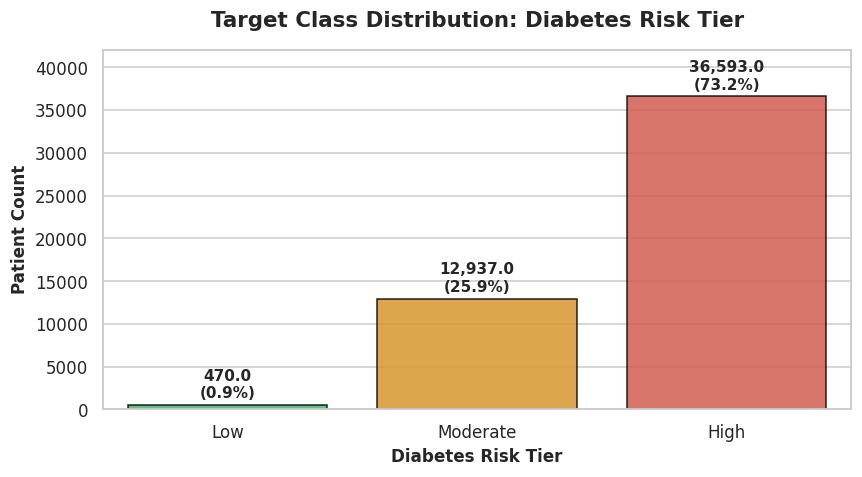

In [2]:
# Cell 2: Data Ingestion & Target Distribution
df = pd.read_csv('../data/interim/cleaned_diabetes_risk_dataset.csv')
print(f"📥 Loaded Cleaned Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Target Tier Distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
palette = {'High': '#e74c3c', 'Moderate': '#f39c12', 'Low': '#2ecc71'}
order = ['Low', 'Moderate', 'High']

counts = df['Diabetes_Risk'].value_counts()
pcts = df['Diabetes_Risk'].value_counts(normalize=True) * 100

bars = sns.barplot(x=counts.index, y=counts.values, order=order, palette=palette, ax=ax, edgecolor='black', alpha=0.85)
ax.set_title('Target Class Distribution: Diabetes Risk Tier', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Diabetes Risk Tier', fontsize=11, fontweight='bold')
ax.set_ylabel('Patient Count', fontsize=11, fontweight='bold')

for bar, tier in zip(bars.patches, order):
    height = bar.get_height()
    pct = pcts[tier]
    ax.text(bar.get_x() + bar.get_width()/2, height + 500, f'{height:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, max(counts.values) * 1.15)
plt.tight_layout()
plt.show()


## 2. Clinical Biomarker Exploratory Data Analysis

We evaluate key physiological indicators across `Diabetes_Risk` categories:
- **Glycemic Control**: `HbA1c` (%), `Fasting_Blood_Sugar` (mg/dL), `Blood_Glucose` (mg/dL), `Insulin_Level` ($\mu\text{IU/mL}$).
- **Lipid Profile**: `Total_Cholesterol`, `HDL`, `LDL`, `Triglycerides`.

### 🩺 Clinical Rationale
- **`HbA1c`**: Reflects average blood glucose over the past 2–3 months. Values $\ge 6.5\%$ are diagnostic for diabetes.
- **`Fasting_Blood_Sugar`**: Values $\ge 126\text{ mg/dL}$ indicate diabetes; $100\text{--}125\text{ mg/dL}$ indicates prediabetes.
- **`Triglycerides` & `HDL`**: High triglycerides ($\ge 150\text{ mg/dL}$) and low HDL ($< 40\text{--}50\text{ mg/dL}$) strongly correlate with metabolic syndrome and insulin resistance.


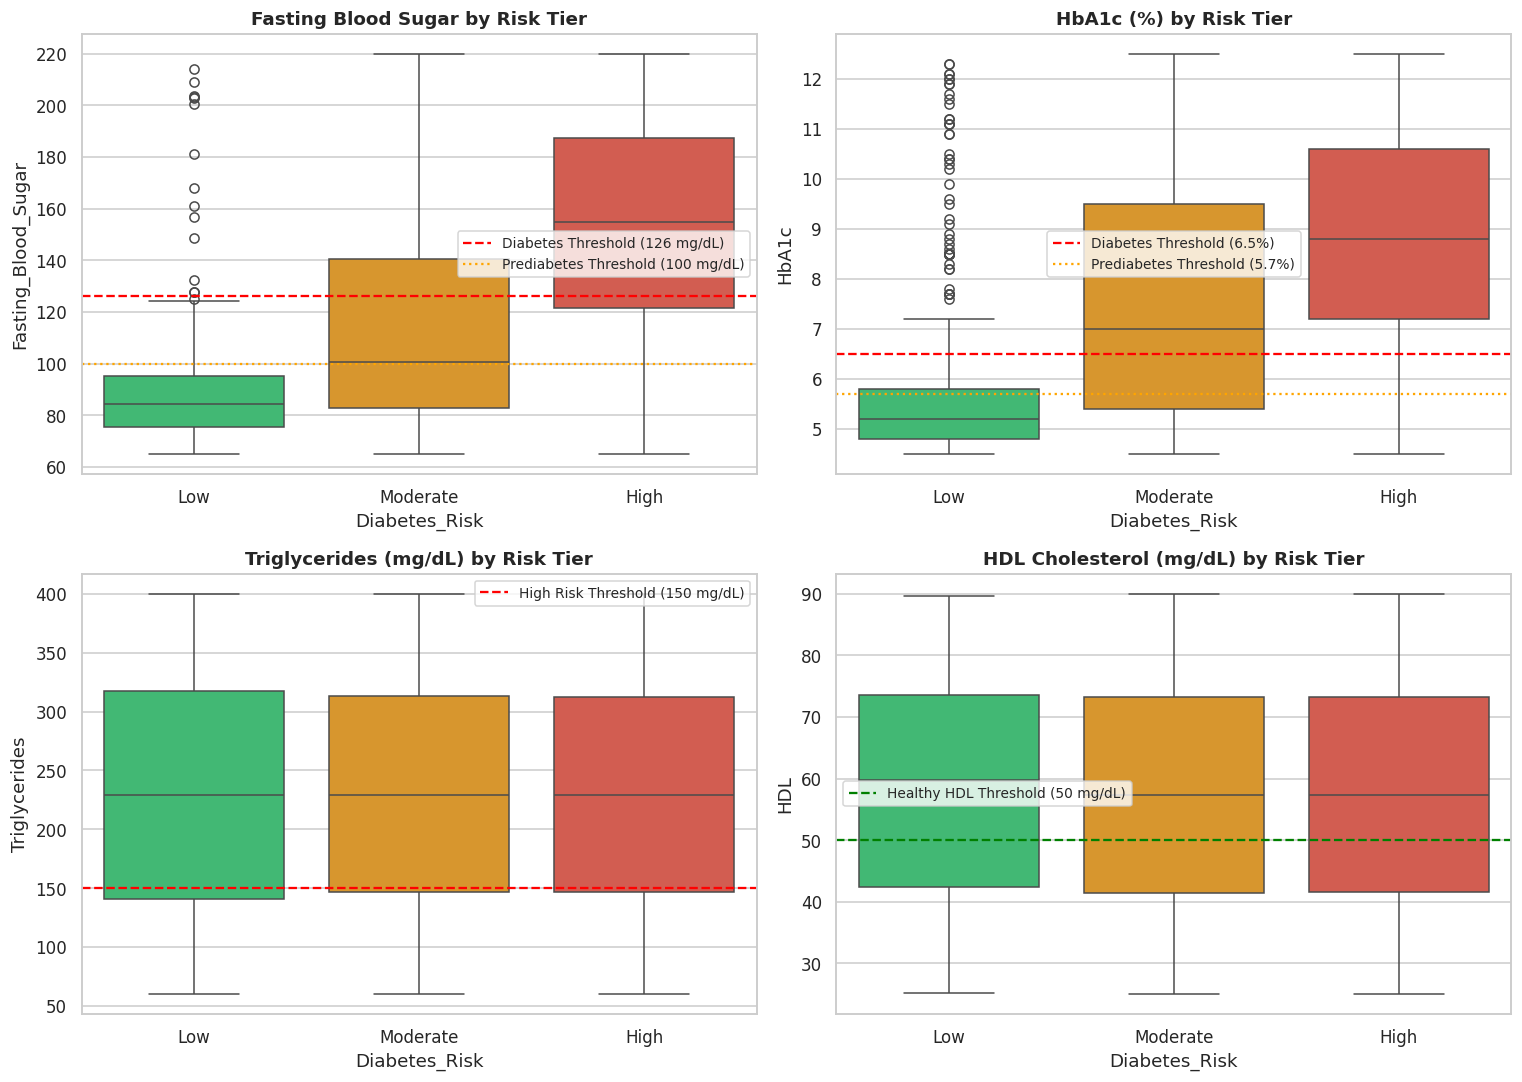

In [3]:
# Cell 3: Clinical Biomarker Boxplots Across Risk Tiers
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Fasting Blood Sugar
sns.boxplot(data=df, x='Diabetes_Risk', y='Fasting_Blood_Sugar', order=['Low', 'Moderate', 'High'], palette=palette, ax=axes[0, 0])
axes[0, 0].axhline(y=126, color='red', linestyle='--', label='Diabetes Threshold (126 mg/dL)')
axes[0, 0].axhline(y=100, color='orange', linestyle=':', label='Prediabetes Threshold (100 mg/dL)')
axes[0, 0].set_title('Fasting Blood Sugar by Risk Tier', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=9)

# 2. HbA1c
sns.boxplot(data=df, x='Diabetes_Risk', y='HbA1c', order=['Low', 'Moderate', 'High'], palette=palette, ax=axes[0, 1])
axes[0, 1].axhline(y=6.5, color='red', linestyle='--', label='Diabetes Threshold (6.5%)')
axes[0, 1].axhline(y=5.7, color='orange', linestyle=':', label='Prediabetes Threshold (5.7%)')
axes[0, 1].set_title('HbA1c (%) by Risk Tier', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=9)

# 3. Triglycerides
sns.boxplot(data=df, x='Diabetes_Risk', y='Triglycerides', order=['Low', 'Moderate', 'High'], palette=palette, ax=axes[1, 0])
axes[1, 0].axhline(y=150, color='red', linestyle='--', label='High Risk Threshold (150 mg/dL)')
axes[1, 0].set_title('Triglycerides (mg/dL) by Risk Tier', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=9)

# 4. HDL (Good Cholesterol)
sns.boxplot(data=df, x='Diabetes_Risk', y='HDL', order=['Low', 'Moderate', 'High'], palette=palette, ax=axes[1, 1])
axes[1, 1].axhline(y=50, color='green', linestyle='--', label='Healthy HDL Threshold (50 mg/dL)')
axes[1, 1].set_title('HDL Cholesterol (mg/dL) by Risk Tier', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.show()


## 3. Lifestyle Factors & Comorbidities EDA

We evaluate lifestyle behavioral indicators (`Diet_Quality`, `Smoking_Status`, `Exercise_Hours_Per_Week`, `Sleep_Hours`) and metabolic comorbidities (`Hypertension`, `Fatty_Liver`, `Heart_Disease`, `PCOS`, `Family_History_Diabetes`).


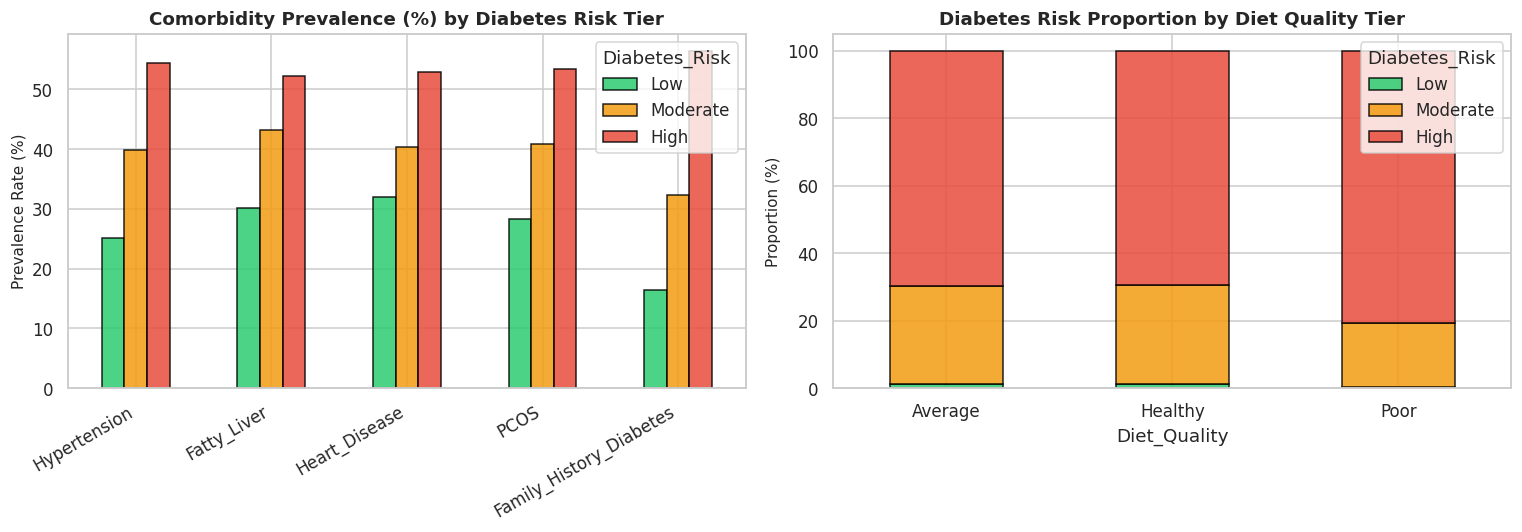

In [4]:
# Cell 4: Comorbidity Prevalence & Lifestyle Factor Breakdown
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Comorbidity Prevalence Across Risk Tiers
comorbidities = ['Hypertension', 'Fatty_Liver', 'Heart_Disease', 'PCOS', 'Family_History_Diabetes']
comorb_df = df.groupby('Diabetes_Risk')[comorbidities].apply(lambda g: (g == 'Yes').mean() * 100).T[['Low', 'Moderate', 'High']]

comorb_df.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', alpha=0.85)
axes[0].set_title('Comorbidity Prevalence (%) by Diabetes Risk Tier', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Prevalence Rate (%)', fontsize=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# 2. Diet Quality vs Diabetes Risk Stacked Bar
ct_diet = pd.crosstab(df['Diet_Quality'], df['Diabetes_Risk'], normalize='index')[['Low', 'Moderate', 'High']] * 100
ct_diet.plot(kind='bar', stacked=True, color=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[1], edgecolor='black', alpha=0.85)
axes[1].set_title('Diabetes Risk Proportion by Diet Quality Tier', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Proportion (%)', fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


## 4. Advanced Medical & Domain Feature Engineering

We create domain-engineered variables rooted in medical literature to improve feature representation for machine learning algorithms:

### 🔬 1. Glycemic Control & Insulin Sensitivity Ratios
- **`HbA1c_Glucose_Ratio`**: $\frac{\text{HbA1c}}{\text{Blood\_Glucose}}$ — Measures concordance between long-term (3-month) glycated hemoglobin and immediate glucose levels.
- **`Glucose_Insulin_Ratio`**: $\frac{\text{Fasting\_Blood\_Sugar}}{\text{Insulin\_Level} + 10^{-5}}$ — Proxy index for insulin resistance (similar to HOMA-IR surrogate models).

### 🫀 2. Cardiovascular & Atherogenic Lipid Ratios
- **`Atherogenic_Index`**: $\frac{\text{Triglycerides}}{\text{HDL}}$ — Key clinical ratio for dyslipidemia and cardiovascular-diabetic risk assessment.
- **`Total_Cholesterol_HDL_Ratio`**: $\frac{\text{Total\_Cholesterol}}{\text{HDL}}$ — Standard coronary risk index.
- **`LDL_HDL_Ratio`**: $\frac{\text{LDL}}{\text{HDL}}$ — Atherogenic lipoprotein balance.
- **`Mean_Arterial_Pressure` ($\text{MAP}$)**: $\text{Blood\_Pressure\_Diastolic} + \frac{1}{3}(\text{Blood\_Pressure\_Systolic} - \text{Blood\_Pressure\_Diastolic})$ — Average arterial pressure during a cardiac cycle.
- **`Pulse_Pressure`**: $\text{Blood\_Pressure\_Systolic} - \text{Blood\_Pressure\_Diastolic}$ — Measure of arterial stiffness.

### 🏃 3. Aggregated Physical Activity & Composite Risk Scores
- **`Total_Active_Hours_Weekly`**: $\text{Exercise\_Hours\_Per\_Week} + \frac{\text{Daily\_Walking\_Minutes} \times 7}{60}$ — Total combined weekly physical activity hours.
- **`Metabolic_Syndrome_Risk_Score`**: Composite 0–5 index summing clinical threshold indicators:
  - Abdominal Obesity ($\text{Waist\_Circumference\_cm} > 90$)
  - Elevated Blood Pressure ($\text{Systolic} \ge 130$ OR $\text{Diastolic} \ge 85$ OR $\text{Hypertension} == \text{'Yes'}$)
  - Hyperglycemia ($\text{Fasting\_Blood\_Sugar} \ge 100$)
  - High Triglycerides ($\text{Triglycerides} \ge 150$)
  - Low HDL ($\text{HDL} < 45$)
- **`Comorbidity_Count`**: Total count of active comorbidities (`Hypertension` + `Heart_Disease` + `Fatty_Liver` + `PCOS` + `Family_History_Diabetes`).


In [5]:
# Cell 5: Constructing Domain-Engineered Features
df_fe = df.copy()

# 1. Glycemic Ratios
df_fe['HbA1c_Glucose_Ratio'] = (df_fe['HbA1c'] / df_fe['Blood_Glucose']).round(4)
df_fe['Glucose_Insulin_Ratio'] = (df_fe['Fasting_Blood_Sugar'] / (df_fe['Insulin_Level'] + 1e-5)).round(4)

# 2. Lipid & Cardiovascular Ratios
df_fe['Atherogenic_Index'] = (df_fe['Triglycerides'] / df_fe['HDL']).round(4)
df_fe['Total_Cholesterol_HDL_Ratio'] = (df_fe['Total_Cholesterol'] / df_fe['HDL']).round(4)
df_fe['LDL_HDL_Ratio'] = (df_fe['LDL'] / df_fe['HDL']).round(4)
df_fe['Mean_Arterial_Pressure'] = (df_fe['Blood_Pressure_Diastolic'] + (df_fe['Blood_Pressure_Systolic'] - df_fe['Blood_Pressure_Diastolic'])/3).round(2)
df_fe['Pulse_Pressure'] = df_fe['Blood_Pressure_Systolic'] - df_fe['Blood_Pressure_Diastolic']

# 3. Physical Activity & Composite Risk Scores
df_fe['Total_Active_Hours_Weekly'] = (df_fe['Exercise_Hours_Per_Week'] + (df_fe['Daily_Walking_Minutes'] * 7 / 60)).round(2)

# Binary flags for Metabolic Syndrome components
c1 = (df_fe['Waist_Circumference_cm'] > 90).astype(int)
c2 = ((df_fe['Blood_Pressure_Systolic'] >= 130) | (df_fe['Blood_Pressure_Diastolic'] >= 85) | (df_fe['Hypertension'] == 'Yes')).astype(int)
c3 = (df_fe['Fasting_Blood_Sugar'] >= 100).astype(int)
c4 = (df_fe['Triglycerides'] >= 150).astype(int)
c5 = (df_fe['HDL'] < 45).astype(int)

df_fe['Metabolic_Syndrome_Risk_Score'] = c1 + c2 + c3 + c4 + c5

# Comorbidity Count
comorb_cols = ['Hypertension', 'Heart_Disease', 'Fatty_Liver', 'PCOS', 'Family_History_Diabetes']
df_fe['Comorbidity_Count'] = sum((df_fe[c] == 'Yes').astype(int) for c in comorb_cols)

print(f"✅ Created 10 New Domain Features! Current Columns Count: {df_fe.shape[1]}")
df_fe[['HbA1c_Glucose_Ratio', 'Glucose_Insulin_Ratio', 'Atherogenic_Index', 'Mean_Arterial_Pressure', 'Metabolic_Syndrome_Risk_Score', 'Comorbidity_Count']].head(4)


✅ Created 10 New Domain Features! Current Columns Count: 47


,HbA1c_Glucose_Ratio,Glucose_Insulin_Ratio,Atherogenic_Index,Mean_Arterial_Pressure,Metabolic_Syndrome_Risk_Score,Comorbidity_Count
0,0.1176,5.4562,6.2544,72.00,3,3
1,0.0457,10.8907,8.0871,116.00,5,4
2,0.0444,9.1883,10.2586,105.67,5,2
3,0.0821,5.9319,4.9887,82.00,4,2


## 5. Categorical Feature Encoding Strategy

To prepare the dataset for machine learning models (Random Forest, XGBoost, Logistic Regression, Neural Networks), we transform categorical strings into numerical encodings:

1. **Ordinal Encoding** (Ordered Tiers):
   - `Diet_Quality`: `Poor` (0) $\rightarrow$ `Average` (1) $\rightarrow$ `Healthy` (2)
   - `Sugar_Intake_Level`: `Low` (0) $\rightarrow$ `Moderate` (1) $\rightarrow$ `High` (2)
   - `Stress_Level`: `Low` (0) $\rightarrow$ `Moderate` (1) $\rightarrow$ `High` (2)
   - `Physical_Activity_Level`: `Low` (0) $\rightarrow$ `Moderate` (1) $\rightarrow$ `High` (2)
   - `Medication_Adherence`: `Poor` (0) $\rightarrow$ `Average` (1) $\rightarrow$ `Good` (2)

2. **Binary Medical Flags**:
   - `Family_History_Diabetes`, `Hypertension`, `Heart_Disease`, `Fatty_Liver`, `PCOS`: `Yes` $\rightarrow 1$, `No` $\rightarrow 0$.

3. **One-Hot Encoding** (Nominal Variables):
   - `Gender`, `Country`, `Smoking_Status`, `Alcohol_Consumption`, `Work_Type`, `Residence_Type`.


In [6]:
# Cell 6: Executing Ordinal & One-Hot Encoding
df_encoded = df_fe.copy()

# 1. Ordinal Mappings
ordinal_mappings = {
    'Diet_Quality': {'Poor': 0, 'Average': 1, 'Healthy': 2},
    'Sugar_Intake_Level': {'Low': 0, 'Moderate': 1, 'High': 2},
    'Stress_Level': {'Low': 0, 'Moderate': 1, 'High': 2},
    'Physical_Activity_Level': {'Low': 0, 'Moderate': 1, 'High': 2},
    'Medication_Adherence': {'Poor': 0, 'Average': 1, 'Good': 2}
}

for col, mapping in ordinal_mappings.items():
    df_encoded[col] = df_encoded[col].map(mapping)

# 2. Binary Flags Encoding
binary_cols = ['Family_History_Diabetes', 'Hypertension', 'Heart_Disease', 'Fatty_Liver', 'PCOS']
for col in binary_cols:
    df_encoded[col] = (df_encoded[col] == 'Yes').astype(int)

# 3. One-Hot Encoding Nominal Features
nominal_cols = ['Gender', 'Country', 'Smoking_Status', 'Alcohol_Consumption', 'Work_Type', 'Residence_Type']
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=True, dtype=int)

print(f"✅ Encoding Complete! Feature Matrix Dimensions: {df_encoded.shape[0]:,} rows x {df_encoded.shape[1]} columns")


✅ Encoding Complete! Feature Matrix Dimensions: 50,000 rows x 76 columns


## 6. Feature Importance & Target Correlation Analysis

We train a Random Forest classifier on the engineered feature set to rank the top 20 most influential predictive features for `Diabetes_Risk`.


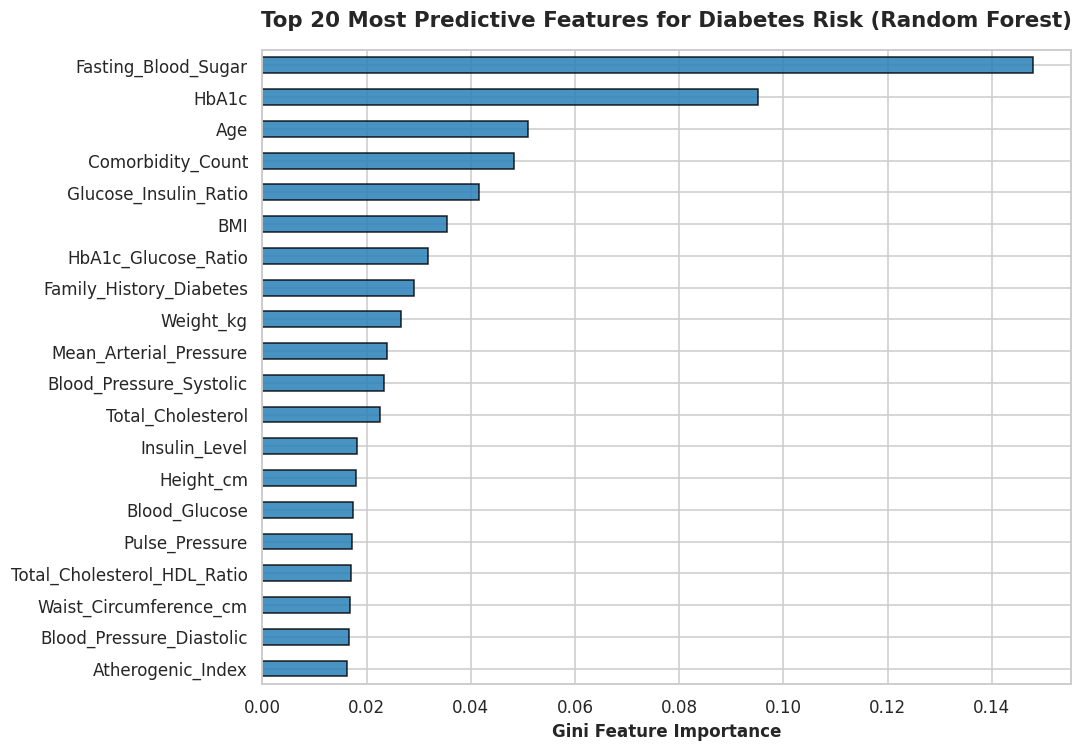

=== TOP 10 ENGINEERED FEATURES BY IMPORTANCE ===


Fasting_Blood_Sugar        0.147858
HbA1c                      0.095065
Age                        0.050989
Comorbidity_Count          0.048220
Glucose_Insulin_Ratio      0.041490
BMI                        0.035512
HbA1c_Glucose_Ratio        0.031763
Family_History_Diabetes    0.029030
Weight_kg                  0.026601
Mean_Arterial_Pressure     0.023963
dtype: float64

In [7]:
# Cell 7: Feature Importance Ranking via Random Forest
X = df_encoded.drop(columns=['Diabetes_Risk'])
y_raw = df_encoded['Diabetes_Risk']

le = LabelEncoder()
y = le.fit_transform(y_raw)

# Fit Random Forest Baseline
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Feature Importance DataFrame
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Visual Audit: Top 20 Feature Importances
plt.figure(figsize=(10, 7))
bars = importances.head(20).plot(kind='barh', color='#2980b9', edgecolor='black', alpha=0.85)
plt.gca().invert_yaxis()
plt.title('Top 20 Most Predictive Features for Diabetes Risk (Random Forest)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Gini Feature Importance', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== TOP 10 ENGINEERED FEATURES BY IMPORTANCE ===")
display(importances.head(10))


## 7. Exporting Engineered Dataset & Final Summary

We export the complete feature-engineered dataset to `data/processed/engineered_diabetes_risk_dataset.csv`.

### 📋 Feature Pipeline Transition Summary

| Feature Category | Count | Primary Features Included |
| :--- | :--- | :--- |
| **Glycemic Control** | 6 | `HbA1c`, `Fasting_Blood_Sugar`, `Blood_Glucose`, `Insulin_Level`, `HbA1c_Glucose_Ratio`, `Glucose_Insulin_Ratio` |
| **Lipids & Cardiovascular** | 10 | `Total_Cholesterol`, `HDL`, `LDL`, `Triglycerides`, `Atherogenic_Index`, `Total_Cholesterol_HDL_Ratio`, `LDL_HDL_Ratio`, `MAP`, `Pulse_Pressure`, `Heart_Rate` |
| **Anthropometrics** | 5 | `Height_cm`, `Weight_kg`, `BMI`, `Waist_Circumference_cm`, `Age` |
| **Composite Scores** | 3 | `Metabolic_Syndrome_Risk_Score`, `Comorbidity_Count`, `Total_Active_Hours_Weekly` |
| **Encodings & Nominals** | 45+ | One-hot encoded countries, gender, smoking, alcohol, work/residence type, and ordinal lifestyle ratings |


In [8]:
# Cell 8: Exporting Engineered Feature Matrix
output_path = '../data/processed/engineered_diabetes_risk_dataset.csv'
df_encoded.to_csv(output_path, index=False)

print(f"🎉 SUCCESS: Feature-engineered dataset saved to '{output_path}'")
print(f"Final Matrix Shape: {df_encoded.shape[0]:,} rows x {df_encoded.shape[1]} columns")
print(f"Total Missing Cells Remaining: {df_encoded.isna().sum().sum()}")


🎉 SUCCESS: Feature-engineered dataset saved to 'engineered_diabetes_risk_dataset.csv'
Final Matrix Shape: 50,000 rows x 76 columns
Total Missing Cells Remaining: 0
